# Task 1

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
df = pd.read_csv('./facebook_combined.txt.gz', compression='gzip', sep=' ', names=['node_1', 'node_2'])

In [ ]:
print(f"Total connections (edges): {len(df)}")

Total connections (edges): 88234


In [12]:
df

,node_1,node_2
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5
...,...,...
88229,4026,4030
88230,4027,4031
88231,4027,4032
88232,4027,4038


In [13]:
G = nx.from_pandas_edgelist(
    df,
    source='node_1',
    target='node_2'
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 4039
Edges: 88234


In [ ]:
largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc)
nodes_sample = list(G_cc.nodes())[:300]  
G_vis = G_cc.subgraph(nodes_sample)

In [ ]:
center = max(G.degree, key=lambda x: x[1])[0]  # highest-degree node
G_vis = nx.ego_graph(G, center, radius=2)

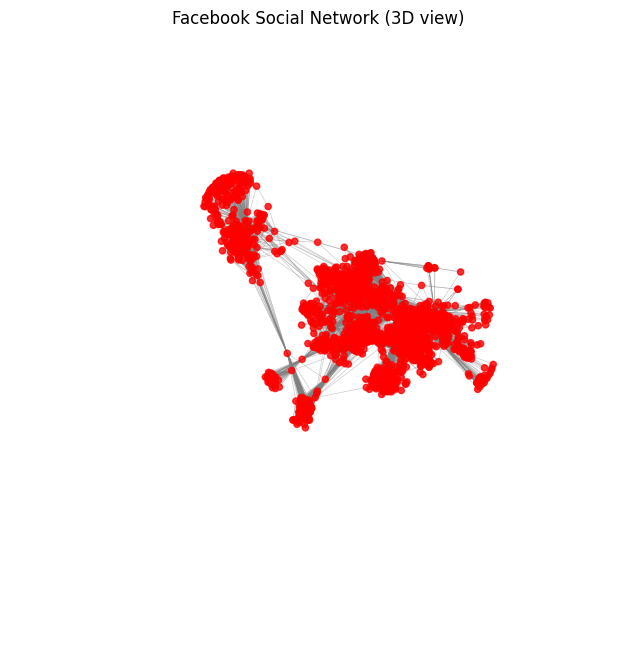

In [16]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 3D spring layout
pos = nx.spring_layout(G_vis, dim=3, seed=42)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw edges
for u, v in G_vis.edges():
    x = [pos[u][0], pos[v][0]]
    y = [pos[u][1], pos[v][1]]
    z = [pos[u][2], pos[v][2]]
    ax.plot(x, y, z, color='gray', alpha=0.4, linewidth=0.5)

# Draw nodes
xs = [pos[n][0] for n in G_vis.nodes()]
ys = [pos[n][1] for n in G_vis.nodes()]
zs = [pos[n][2] for n in G_vis.nodes()]

ax.scatter(xs, ys, zs, s=20, c='red', alpha=0.8)

ax.set_title("Facebook Social Network (3D view)")
ax.set_axis_off()

plt.show()


In [ ]:
import gzip
import collections

class SocialGraph:
    def __init__(self):
        # Adjacency list: {node: [neighbors]}
        self.adj = collections.defaultdict(list)
        self.nodes = set()

    def add_edge(self, u, v):
        self.adj[u].append(v)
        self.adj[v].append(u)
        self.nodes.add(u)
        self.nodes.add(v)

    def load_from_gzip(self, filepath):
        print(f"Loading data from {filepath}...")
        with gzip.open(filepath, 'rt') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    u, v = int(parts[0]), int(parts[1])
                    self.add_edge(u, v)
        print(f"Graph loaded: {len(self.nodes)} nodes.")


    def find_connected_components(self):
        """
        Uses BFS to find all isolated groups of users (components).
        """
        visited = set()
        components = []

        for node in self.nodes:
            if node not in visited:
                component = []
                queue = collections.deque([node])
                visited.add(node)
                component.append(node)

                while queue:
                    curr = queue.popleft()
                    for neighbor in self.adj[curr]:
                        if neighbor not in visited:
                            visited.add(neighbor)
                            component.append(neighbor)
                            queue.append(neighbor)
                components.append(component)
        
        return components
   
    def bfs_shortest_paths_from(self, source):
        if source not in self.nodes:
            raise KeyError(f"Source {source} not in graph")

        dist = {source: 0}
        q = collections.deque([source])
        while q:
            cur = q.popleft()
            for nb in self.adj[cur]:
                if nb not in dist:
                    dist[nb] = dist[cur] + 1
                    q.append(nb)
        return dist

    def shortest_path(self, source, target):
        if source not in self.nodes or target not in self.nodes:
            raise KeyError("Source or target not in graph")
        if source == target:
            return [source]

        pred = {source: None}
        q = collections.deque([source])
        found = False
        while q and not found:
            cur = q.popleft()
            for nb in self.adj[cur]:
                if nb not in pred:
                    pred[nb] = cur
                    if nb == target:
                        found = True
                        break
                    q.append(nb)
        if not found:
            return None

        # reconstruct path
        path = []
        cur = target
        while cur is not None:
            path.append(cur)
            cur = pred[cur]
        path.reverse()
        return path

    def reach_over_time_from(self, source):
        dist = self.bfs_shortest_paths_from(source)
        if not dist:
            return []

        maxd = max(dist.values())
        # count nodes at each distance
        counts = [0] * (maxd + 1)
        for d in dist.values():
            counts[d] += 1
        # cumulative reach
        cum = []
        total = 0
        for t in range(len(counts)):
            total += counts[t]
            cum.append(total)
        return cum  # cum[t] = nodes reached by time t
    
    def degree_centrality_top10(self):
        degree = {node: len(self.adj[node]) for node in self.nodes}
        top10 = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]
        return top10
    
    def closeness_centrality_top10(self):
        closeness = {}

        for node in self.nodes:
            dist = self.bfs_shortest_paths_from(node)
            if len(dist) > 1:
                closeness[node] = (len(dist) - 1) / sum(dist.values())
            else:
                closeness[node] = 0

        top10 = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
        return top10
    
    def betweenness_centrality_top10(self):
        betweenness = {v: 0.0 for v in self.nodes}

        for s in self.nodes:
            stack = []
            pred = {w: [] for w in self.nodes}
            sigma = dict.fromkeys(self.nodes, 0)
            dist = dict.fromkeys(self.nodes, -1)

            sigma[s] = 1
            dist[s] = 0

            queue = collections.deque([s])
            while queue:
                v = queue.popleft()
                stack.append(v)
                for w in self.adj[v]:
                    if dist[w] < 0:
                        dist[w] = dist[v] + 1
                        queue.append(w)
                    if dist[w] == dist[v] + 1:
                        sigma[w] += sigma[v]
                        pred[w].append(v)

            delta = dict.fromkeys(self.nodes, 0)
            while stack:
                w = stack.pop()
                for v in pred[w]:
                    delta[v] += (sigma[v] / sigma[w]) * (1 + delta[w])
                if w != s:
                    betweenness[w] += delta[w]

        # undirected graph → divide by 2
        for v in betweenness:
            betweenness[v] /= 2

        top10 = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
        return top10



In [27]:
G = SocialGraph()
G.load_from_gzip("facebook_combined.txt.gz")

Loading data from facebook_combined.txt.gz...
Graph loaded: 4039 nodes.


In [28]:
comps = G.find_connected_components()
print(f"Number of Connected Components: {len(comps)}")
print(f"Size of Largest Component: {max(len(c) for c in comps)}")

Number of Connected Components: 1
Size of Largest Component: 4039


In [ ]:
start_path = 0
end_path = 1234
 
# 1) shortest-path distances from start
distances = G.bfs_shortest_paths_from(start_path)
print("Reached:", len(distances), "nodes")

# 2) one actual shortest path 
path = G.shortest_path(start_path, end_path)   
print("Path from", start_path, "to", end_path, ":", path)


# 3) deterministic reach-over-time (hop t = time t)
reach_by_time = G.reach_over_time_from(start_path)
for t, cum in enumerate(reach_by_time):
    print(f"time {t}: {cum} nodes reached (cumulative)")

Reached: 4039 nodes
Path from 0 to 1234 : [0, 107, 1234]
time 0: 1 nodes reached (cumulative)
time 1: 348 nodes reached (cumulative)
time 2: 1519 nodes reached (cumulative)
time 3: 3261 nodes reached (cumulative)
time 4: 3780 nodes reached (cumulative)
time 5: 3897 nodes reached (cumulative)
time 6: 4039 nodes reached (cumulative)


In [30]:
degree = G.degree_centrality_top10()
closeness = G.closeness_centrality_top10()
betweenness = G.betweenness_centrality_top10()

print("Top 10 by degree:")
print(degree)

print("\nTop 10 by closeness:")
print(closeness)

print("\nTop 10 by betweenness:")
print(betweenness)

Top 10 by degree:
[(107, 1045), (1684, 792), (1912, 755), (3437, 547), (0, 347), (2543, 294), (2347, 291), (1888, 254), (1800, 245), (1663, 235)]

Top 10 by closeness:
[(107, 0.45969945355191255), (58, 0.3974018305284913), (428, 0.3948371956585509), (563, 0.3939127889961955), (1684, 0.39360561458231796), (171, 0.37049270575282134), (348, 0.36991572004397216), (483, 0.3698479575013739), (414, 0.3695433330282786), (376, 0.36655773420479304)]

Top 10 by betweenness:
[(107, 3916560.1444407436), (1684, 2753286.6869082903), (3437, 1924506.1515714861), (1912, 1868918.2122567892), (1085, 1214577.7583604748), (0, 1192496.1130793886), (698, 940024.2464821987), (567, 784996.9055941292), (58, 687594.9833746809), (428, 524164.067775757)]


In [31]:
# Extract node IDs only
degree_nodes = {n for n, _ in degree}
closeness_nodes = {n for n, _ in closeness}
betweenness_nodes = {n for n, _ in betweenness}

# Nodes appearing in ALL three
core_nodes = degree_nodes & closeness_nodes & betweenness_nodes

print("Nodes common to degree, closeness, and betweenness:")
print(core_nodes)

Nodes common to degree, closeness, and betweenness:
{107, 1684}


# Task 2

In [ ]:
import tarfile
import pandas as pd

# Open the tarball
tar = tarfile.open("./facebook.tar.gz", "r:gz")

# List all files inside
print("Files in the archive:")
for member in tar.getmembers()[:50]:
    print(member.name)

Files in the archive:
facebook
facebook/3980.egofeat
facebook/0.featnames
facebook/698.egofeat
facebook/3437.feat
facebook/3980.featnames
facebook/0.edges
facebook/3437.circles
facebook/686.circles
facebook/348.egofeat
facebook/107.feat
facebook/348.feat
facebook/1912.circles
facebook/3437.egofeat
facebook/698.feat
facebook/348.edges
facebook/1912.feat
facebook/414.circles
facebook/1684.egofeat
facebook/1684.featnames
facebook/1684.feat
facebook/107.egofeat
facebook/0.circles
facebook/414.edges
facebook/698.featnames
facebook/698.edges
facebook/1912.featnames
facebook/107.edges
facebook/107.circles
facebook/0.egofeat
facebook/414.featnames
facebook/3980.feat
facebook/3437.featnames
facebook/1912.egofeat
facebook/414.egofeat
facebook/698.circles
facebook/348.featnames
facebook/348.circles
facebook/0.feat
facebook/1684.circles
facebook/3437.edges
facebook/3980.edges
facebook/686.featnames
facebook/1912.edges
facebook/3980.circles
facebook/686.feat
facebook/1684.edges
facebook/414.feat
fa

In [57]:
import os
import re

BASE = "facebook_data/facebook"

ego_ids = sorted({
    int(re.match(r"(\d+)\.", f).group(1))
    for f in os.listdir(BASE)
    if f.endswith(".featnames")
})

print("Ego networks:", ego_ids)


Ego networks: [0, 107, 348, 414, 686, 698, 1684, 1912, 3437, 3980]


In [ ]:
import numpy as np

f_feat = tar.extractfile("facebook/0.feat")
features_raw = [line.decode('utf-8').split() for line in f_feat.readlines()]

df_features = pd.DataFrame(features_raw).astype(int)
df_features.columns = ['user_id'] + [f"feat_{i}" for i in range(df_features.shape[1] - 1)]

display(df_features)

,user_id,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,...,feat_214,feat_215,feat_216,feat_217,feat_218,feat_219,feat_220,feat_221,feat_222,feat_223
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,343,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
343,344,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
344,345,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
345,346,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
f = tar.extractfile("facebook/0.featnames")
if f:
    # Read the first 5 feature names
    content = f.read().decode('utf-8').splitlines()
    print("\nSample Feature Names for Node 0:")
    for line in content:
        print(line)


Sample Feature Names for Node 0:
0 birthday;anonymized feature 0
1 birthday;anonymized feature 1
2 birthday;anonymized feature 2
3 birthday;anonymized feature 3
4 birthday;anonymized feature 4
5 birthday;anonymized feature 5
6 birthday;anonymized feature 6
7 birthday;anonymized feature 7
8 education;classes;id;anonymized feature 8
9 education;classes;id;anonymized feature 9
10 education;classes;id;anonymized feature 10
11 education;classes;id;anonymized feature 11
12 education;classes;id;anonymized feature 12
13 education;concentration;id;anonymized feature 13
14 education;concentration;id;anonymized feature 14
15 education;concentration;id;anonymized feature 15
16 education;concentration;id;anonymized feature 16
17 education;concentration;id;anonymized feature 17
18 education;concentration;id;anonymized feature 18
19 education;concentration;id;anonymized feature 19
20 education;degree;id;anonymized feature 20
21 education;degree;id;anonymized feature 21
22 education;degree;id;anonymi

In [36]:
import tarfile
import os

tar_path = "facebook.tar.gz"
extract_dir = "facebook_data"

os.makedirs(extract_dir, exist_ok=True)

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=extract_dir)

print("Extraction complete.")


Extraction complete.


In [37]:
BASE = "facebook_data/facebook"

In [38]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

In [39]:
def load_featnames(path):
    featnames = {}
    with open(path, 'r') as f:
        for line in f:
            idx, name = line.strip().split(' ', 1)
            featnames[int(idx)] = name
    return featnames

In [40]:
def load_feat(path):
    user_features = {}
    with open(path, 'r') as f:
        for line in f:
            parts = list(map(int, line.strip().split()))
            user_id = parts[0]
            features = parts[1:]
            user_features[user_id] = features
    return user_features

In [61]:
featnames = load_featnames(f"{BASE}/0.featnames")
user_features = load_feat(f"{BASE}/0.feat")

In [60]:
featnames

{0: 'birthday;anonymized feature 0',
 1: 'birthday;anonymized feature 1',
 2: 'birthday;anonymized feature 2',
 3: 'birthday;anonymized feature 3',
 4: 'birthday;anonymized feature 4',
 5: 'birthday;anonymized feature 5',
 6: 'birthday;anonymized feature 6',
 7: 'birthday;anonymized feature 7',
 8: 'education;classes;id;anonymized feature 8',
 9: 'education;classes;id;anonymized feature 9',
 10: 'education;classes;id;anonymized feature 10',
 11: 'education;classes;id;anonymized feature 11',
 12: 'education;classes;id;anonymized feature 12',
 13: 'education;concentration;id;anonymized feature 13',
 14: 'education;concentration;id;anonymized feature 14',
 15: 'education;concentration;id;anonymized feature 15',
 16: 'education;concentration;id;anonymized feature 16',
 17: 'education;concentration;id;anonymized feature 17',
 18: 'education;concentration;id;anonymized feature 18',
 19: 'education;concentration;id;anonymized feature 19',
 20: 'education;degree;id;anonymized feature 20',
 21:

In [63]:
user_features

{1: [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

In [42]:
school_features = {
    idx: name
    for idx, name in featnames.items()
    if "education;school;id" in name
}

print(f"Number of school features: {len(school_features)}")

Number of school features: 29


In [64]:
school_features

{24: 'education;school;id;anonymized feature 24',
 25: 'education;school;id;anonymized feature 25',
 26: 'education;school;id;anonymized feature 26',
 27: 'education;school;id;anonymized feature 27',
 28: 'education;school;id;anonymized feature 28',
 29: 'education;school;id;anonymized feature 29',
 30: 'education;school;id;anonymized feature 30',
 31: 'education;school;id;anonymized feature 31',
 32: 'education;school;id;anonymized feature 32',
 33: 'education;school;id;anonymized feature 33',
 34: 'education;school;id;anonymized feature 34',
 35: 'education;school;id;anonymized feature 35',
 36: 'education;school;id;anonymized feature 36',
 37: 'education;school;id;anonymized feature 37',
 38: 'education;school;id;anonymized feature 38',
 39: 'education;school;id;anonymized feature 39',
 40: 'education;school;id;anonymized feature 40',
 41: 'education;school;id;anonymized feature 41',
 42: 'education;school;id;anonymized feature 42',
 43: 'education;school;id;anonymized feature 43',


In [43]:
user_to_schools = defaultdict(list)
school_popularity = defaultdict(int)

for user, feats in user_features.items():
    for feat_idx in school_features:
        if feats[feat_idx] == 1:
            school = school_features[feat_idx]
            user_to_schools[user].append(school)
            school_popularity[school] += 1

In [65]:
user_to_schools

{2: ['education;school;id;anonymized feature 35'],
 3: ['education;school;id;anonymized feature 34',
  'education;school;id;anonymized feature 50'],
 4: ['education;school;id;anonymized feature 50'],
 5: ['education;school;id;anonymized feature 49',
  'education;school;id;anonymized feature 50'],
 7: ['education;school;id;anonymized feature 25',
  'education;school;id;anonymized feature 43',
  'education;school;id;anonymized feature 50'],
 10: ['education;school;id;anonymized feature 50'],
 12: ['education;school;id;anonymized feature 39'],
 13: ['education;school;id;anonymized feature 50'],
 14: ['education;school;id;anonymized feature 39'],
 15: ['education;school;id;anonymized feature 43'],
 16: ['education;school;id;anonymized feature 50'],
 17: ['education;school;id;anonymized feature 28',
  'education;school;id;anonymized feature 39'],
 18: ['education;school;id;anonymized feature 47',
  'education;school;id;anonymized feature 50'],
 19: ['education;school;id;anonymized feature 3

In [67]:
len(user_to_schools)

222

In [66]:
school_popularity

defaultdict(int,
            {'education;school;id;anonymized feature 35': 8,
             'education;school;id;anonymized feature 34': 2,
             'education;school;id;anonymized feature 50': 153,
             'education;school;id;anonymized feature 49': 4,
             'education;school;id;anonymized feature 25': 2,
             'education;school;id;anonymized feature 43': 6,
             'education;school;id;anonymized feature 39': 14,
             'education;school;id;anonymized feature 28': 2,
             'education;school;id;anonymized feature 47': 8,
             'education;school;id;anonymized feature 38': 8,
             'education;school;id;anonymized feature 45': 12,
             'education;school;id;anonymized feature 27': 3,
             'education;school;id;anonymized feature 33': 5,
             'education;school;id;anonymized feature 31': 3,
             'education;school;id;anonymized feature 40': 4,
             'education;school;id;anonymized feature 52': 17,
  

In [68]:
user_to_schools = {
    u: s for u, s in user_to_schools.items() if len(s) > 0
}

In [69]:
len(user_to_schools)

222

In [70]:
alpha = 0.5  # 50% of observed popularity

school_capacity = {
    school: max(1, int(alpha * count))
    for school, count in school_popularity.items()
}


In [71]:
school_capacity

{'education;school;id;anonymized feature 35': 4,
 'education;school;id;anonymized feature 34': 1,
 'education;school;id;anonymized feature 50': 76,
 'education;school;id;anonymized feature 49': 2,
 'education;school;id;anonymized feature 25': 1,
 'education;school;id;anonymized feature 43': 3,
 'education;school;id;anonymized feature 39': 7,
 'education;school;id;anonymized feature 28': 1,
 'education;school;id;anonymized feature 47': 4,
 'education;school;id;anonymized feature 38': 4,
 'education;school;id;anonymized feature 45': 6,
 'education;school;id;anonymized feature 27': 1,
 'education;school;id;anonymized feature 33': 2,
 'education;school;id;anonymized feature 31': 1,
 'education;school;id;anonymized feature 40': 2,
 'education;school;id;anonymized feature 52': 8,
 'education;school;id;anonymized feature 48': 1,
 'education;school;id;anonymized feature 26': 1,
 'education;school;id;anonymized feature 44': 3,
 'education;school;id;anonymized feature 24': 1,
 'education;school;

In [76]:
from collections import defaultdict, deque

SOURCE = "__source__"
SINK = "__sink__"

# Flow capacity graph
capacity = defaultdict(dict)

# SOURCE → users (each user can be assigned once)
for user in user_to_schools:
    capacity[SOURCE][user] = 1

# user → school (only if user has that school feature)
for user, schools in user_to_schools.items():
    for school in schools:
        capacity[user][school] = 1

# school → SINK (capacity proportional to popularity)
for school, cap in school_capacity.items():
    capacity[school][SINK] = cap


In [77]:
capacity

defaultdict(dict,
            {'__source__': {2: 1,
              3: 1,
              4: 1,
              5: 1,
              7: 1,
              10: 1,
              12: 1,
              13: 1,
              14: 1,
              15: 1,
              16: 1,
              17: 1,
              18: 1,
              19: 1,
              22: 1,
              23: 1,
              24: 1,
              25: 1,
              27: 1,
              29: 1,
              31: 1,
              35: 1,
              36: 1,
              38: 1,
              40: 1,
              44: 1,
              45: 1,
              46: 1,
              47: 1,
              48: 1,
              49: 1,
              50: 1,
              52: 1,
              55: 1,
              56: 1,
              57: 1,
              58: 1,
              59: 1,
              60: 1,
              62: 1,
              63: 1,
              64: 1,
              65: 1,
              66: 1,
              67: 1,
              68: 1,
       

In [ ]:
def edmonds_karp(capacity, source, sink):
    residual = defaultdict(dict)

    # Initialize residual graph
    for u in capacity:
        for v, cap in capacity[u].items():
            residual[u][v] = cap
            residual[v][u] = 0

    max_flow = 0
    parent = {}

    def bfs():
        visited = set([source])
        queue = deque([source])
        parent.clear()

        while queue:
            u = queue.popleft()
            for v, cap in residual[u].items():
                if v not in visited and cap > 0:
                    visited.add(v)
                    parent[v] = u
                    if v == sink:
                        return True
                    queue.append(v)
        return False

    while bfs():
        # Find bottleneck capacity
        flow = float('inf')
        v = sink
        while v != source:
            u = parent[v]
            flow = min(flow, residual[u][v])
            v = u

        # Update residual graph
        v = sink
        while v != source:
            u = parent[v]
            residual[u][v] -= flow
            residual[v][u] += flow
            v = u

        max_flow += flow

    return max_flow, residual

In [85]:
max_flow, residual = edmonds_karp(capacity, SOURCE, SINK)

print("Maximum number of assigned users:", max_flow)

print("residual:", residual)

Maximum number of assigned users: 138
residual: defaultdict(<class 'dict'>, {'__source__': {2: 0, 3: 0, 4: 0, 5: 0, 7: 0, 10: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 22: 0, 23: 0, 24: 0, 25: 0, 27: 0, 29: 0, 31: 0, 35: 0, 36: 0, 38: 0, 40: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 0, 52: 0, 55: 0, 56: 0, 57: 0, 58: 0, 59: 0, 60: 0, 62: 0, 63: 0, 64: 0, 65: 0, 66: 0, 67: 0, 68: 0, 69: 0, 72: 0, 73: 0, 75: 0, 77: 0, 79: 0, 80: 0, 81: 0, 82: 0, 83: 1, 84: 0, 85: 0, 87: 0, 91: 0, 92: 0, 94: 0, 95: 0, 100: 0, 101: 0, 102: 0, 103: 0, 104: 0, 105: 0, 107: 0, 109: 0, 111: 0, 113: 0, 114: 0, 115: 0, 116: 0, 117: 0, 118: 0, 119: 0, 120: 0, 121: 0, 122: 0, 123: 0, 126: 0, 128: 0, 129: 0, 132: 0, 133: 0, 134: 0, 135: 0, 140: 1, 141: 0, 142: 0, 143: 0, 144: 0, 146: 0, 147: 0, 148: 0, 150: 0, 152: 0, 153: 0, 155: 0, 156: 0, 157: 0, 158: 0, 159: 0, 160: 0, 161: 0, 163: 0, 165: 0, 167: 0, 168: 0, 169: 0, 170: 0, 171: 0, 172: 0, 173: 0, 175: 0, 176: 0, 177: 0, 178: 0, 180: 0, 

In [ ]:
matching = {}

for user, schools in user_to_schools.items():
    for school in schools:
        if capacity[user].get(school, 0) == 1 and residual[user][school] == 0:
            matching[user] = school

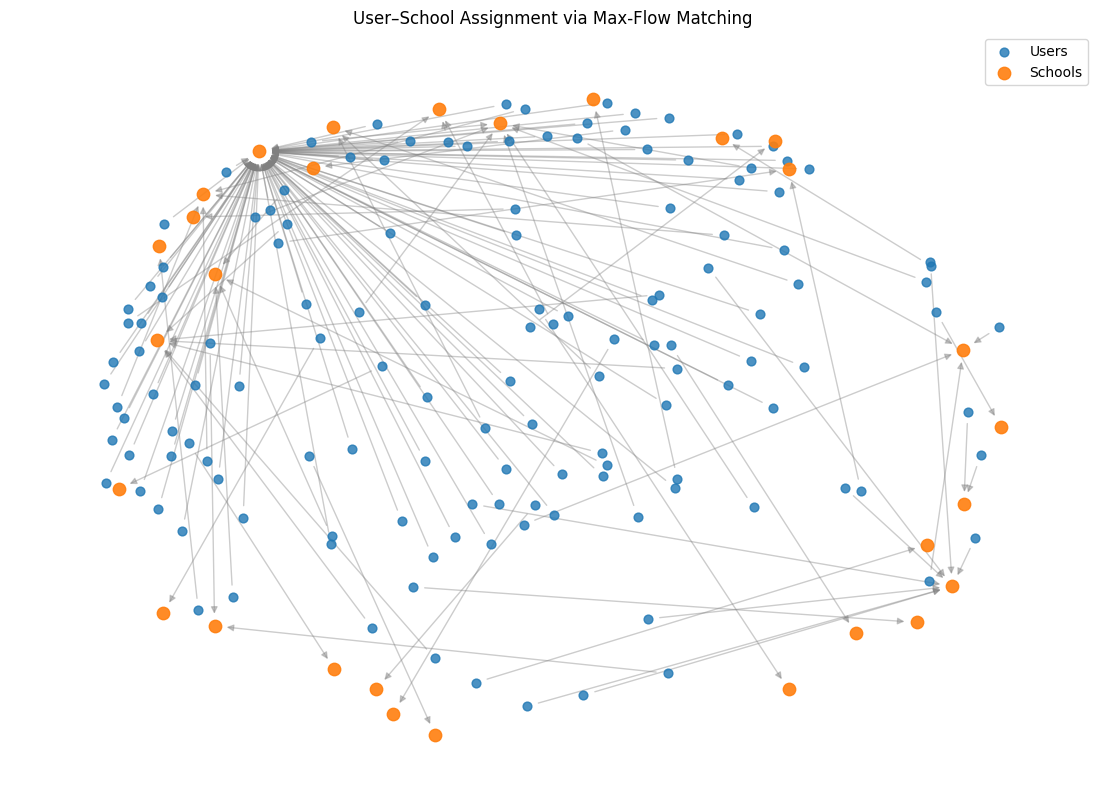

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G_vis = nx.DiGraph()

users = set(matching.keys())
schools = set(matching.values())

# Add edges
for user, school in matching.items():
    G_vis.add_edge(user, school)

# Layout
pos = nx.spring_layout(G_vis, k=0.6, seed=42)

# Separate node lists
user_nodes = list(users)
school_nodes = list(schools)

plt.figure(figsize=(14, 10))

# Draw users 
nx.draw_networkx_nodes(
    G_vis,
    pos,
    nodelist=user_nodes,
    node_color="tab:blue",
    node_size=40,
    alpha=0.8,
    label="Users"
)

# Draw schools
nx.draw_networkx_nodes(
    G_vis,
    pos,
    nodelist=school_nodes,
    node_color="tab:orange",
    node_size=80,
    alpha=0.9,
    label="Schools"
)

# Draw edges
nx.draw_networkx_edges(
    G_vis,
    pos,
    edge_color="gray",
    alpha=0.4
)

plt.legend()
plt.title("User–School Assignment via Max-Flow Matching")
plt.axis("off")
plt.show()
